# Small TTT EDA

In [2]:
import json
from math import floor, ceil
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
# import umap
import itertools
import sklearn
from sklearn.manifold import TSNE
from scipy.optimize import milp, LinearConstraint, Bounds

from data.reps import *
from data.game import generate_states_from_root_board
from train import param_acc_curve
from models.nn import TicTacToeNet
from models.plot_weights import plot_weights

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
in_dim, hidden_dim, out_dim = 9+9,9,9

num_params = (hidden_dim*in_dim + hidden_dim) + (out_dim*hidden_dim + out_dim)
print(f'{in_dim},{hidden_dim},{out_dim} :: Num params: {num_params}')

18,9,9 :: Num params: 261


In [3]:

with open("data/datasets/jsons/all_states.json", "r") as file:
    all_states_dict = json.load(file)

moves_mask = []
legal_moves_mask = []
for key, moves in all_states_dict.items():
    row = [0 for _ in range(9)]
    for move in moves:
        row[move] = 1
    moves_mask.append(row)

    row2 = [0 for _ in range(9)]
    for letter_idx, letter in enumerate(key):
        if letter == ' ':
            row2[letter_idx] = 1
    legal_moves_mask.append(row2)

moves_mask = torch.tensor(moves_mask)
legal_moves_mask = torch.tensor(legal_moves_mask)
print(moves_mask.shape)
print(legal_moves_mask.shape)

row_mask = (~((moves_mask == legal_moves_mask).all(dim=1))).nonzero().squeeze(1)
print(row_mask.shape)
row_mask


all_states_filtered = {}
for idx, (key, moves) in enumerate(all_states_dict.items()):
    if idx in row_mask:
        all_states_filtered[key] = moves

with open('data/datasets/jsons/all_states_filtered.json', 'w') as f:
    json.dump(all_states_filtered, f)

torch.Size([4520, 9])
torch.Size([4520, 9])
torch.Size([3191])


In [ ]:
with open("data/datasets/jsons/all_states.json", "r") as file:
    all_states_dict = json.load(file)

moves_mask = []
for key, moves in all_states_dict.items():
    row = [0 for _ in range(9)]
    for move in moves:
        row[move] = 1
    moves_mask.append(row)
moves_mask = torch.tensor(moves_mask, dtype=torch.bool)
# moves_mask = torch.tensor(moves_mask)
print(f'moves_mask.shape: {moves_mask.shape}')
logits = torch.rand(moves_mask.shape)

uh = torch.nn.functional.log_softmax(logits, dim=1)

# print(logits[0:3])
# print(uh[0:3])

a = moves_mask[0:3]
b = moves_mask[3:6]
print(a)
print(b)

print()
# print(1-moves_mask[0:3])
# print(~moves_mask[0:3])

def one_among_many_loss(logits, moves_mask):
    # NOTE removes row of all True, doesnt matter what the network does
    # TODO there is a better fix for this, pick just corners or something
    logits = logits[1:]
    moves_mask = moves_mask[1:]

    mask_val = -float('inf')
    # good_logits = logits.masked_fill(~moves_mask, mask_val)
    # bad_logits = logits.masked_fill(moves_mask, mask_val)

    good_logits = logits * moves_mask
    bad_logits = logits * (1-moves_mask)

    # loss = (torch.max(bad_logits, dim=1).values - torch.max(good_logits, dim=1).values).mean()

    term_1 = (bad_logits.sum(dim=1) / (1-moves_mask).sum(dim=1).clamp(min=1))
    term_2 = (good_logits.sum(dim=1) / moves_mask.sum(dim=1).clamp(min=1))
    print(term_1.shape)
    print(term_2.shape)
    loss =  term_1 - term_2
    
    return loss.mean()

loss = one_among_many_loss(logits, moves_mask)
loss

moves_mask.shape: torch.Size([4520, 9])
tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True, False, False, False, False],
        [False, False, False,  True,  True, False,  True, False, False]])
tensor([[False, False, False, False,  True, False, False, False, False],
        [False, False, False, False,  True, False, False, False,  True],
        [False, False, False, False, False,  True,  True,  True,  True]])
tensor([], size=(0, 1), dtype=torch.int64)


RuntimeError: Subtraction, the `-` operator, with a bool tensor is not supported. If you are trying to invert a mask, use the `~` or `logical_not()` operator instead.

In [ ]:
HIDDEN_DIMS = [24]
# HIDDEN_DIMS = [16,16]
rep_length = 9
model = TicTacToeNet(
    hidden_sizes=HIDDEN_DIMS,
    input_size=rep_length
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
num_params

465

In [4]:
with open('data/datasets/jsons/nn_friendly_dataset.json', 'rb') as f:
    states_dict = json.load(f)
len(states_dict)

4520

Params: 237, Zero: 67, Model sparcity: 28.270%


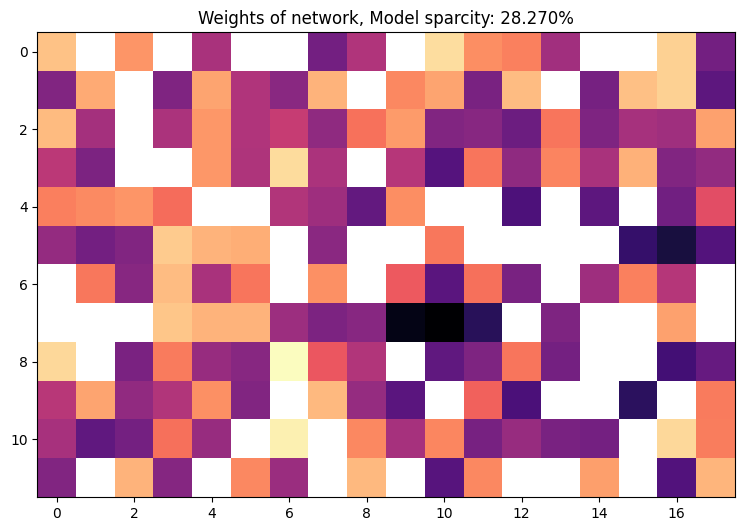

In [2]:
model = TicTacToeNet(
    hidden_sizes=[12],
    input_size=9
)
PATH = 'models/checkpoints/pruning/nn_nonz_170_237_[9, 12, 9].pth'
model.load_state_dict(torch.load(PATH, weights_only=True))

zerocount, total = 0, 0
for param in model.parameters(): 
    tens = param.flatten().tolist()
    for thing in tens:
        total += 1
        if thing == 0:
            zerocount += 1

print(f'Params: {total}, Zero: {zerocount}, Model sparcity: {zerocount/total*100:.3f}%')

plot_weights(model, ispruned=True, title=f'Weights of network, Model sparcity: {zerocount/total*100:.3f}%')

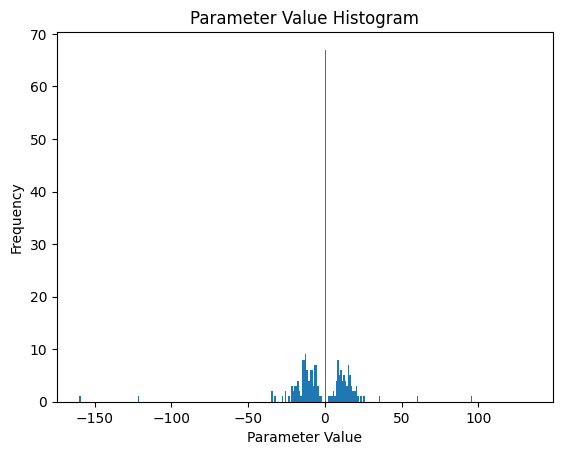

In [3]:
params = []
for param in model.parameters(): params.extend(param.flatten().tolist())
plt.hist(params, bins=np.arange(floor(min(params)), ceil(max(params)), 1))
plt.title('Parameter Value Histogram')
plt.xlabel('Parameter Value')
plt.ylabel('Frequency')
# plt.xscale("log")
print()

In [ ]:
# plot the parameter, accuracy curve

# NOTE 2_500 epochs seed=2, lr=1e-3 hidden_dim=3, 66 params modeled on fixed gets 48.7% on the full dataset, 24 gets 49.6%, 33 49.7%, 57 gets 50.5%
# hidden dim=4, 85 params 28 gets 53.0, 60 get 55.1%, 

EPOCHS = 2_500
best_seed, best_score = None, 0
for seed in range(100):
    x_data, y_data, z_data, model = param_acc_curve(
        param_min=5,
        param_max=6,
        epochs = EPOCHS,
        seed=seed,
    )
    if z_data[0] > best_score:
        best_seed = seed
        best_score = z_data[0]
        print(f'Best seed so far: {best_seed}, at {best_score*100:.4f}%')
    # print(f'Seed: {seed}')
    # for num in y_data: print(f'{num:.3f}', end=', ')
    # print()
    # for num in z_data: print(f'{num:.3f}', end=', ')
    # plt.plot(x_data, y_data, label=f'{seed} Fixed %')
    # plt.plot(x_data, z_data, label=f'{seed} Full %')

num_params = sum(p.numel() for p in model.parameters())

checkpoint_path = f'models/checkpoints/nn_seed_{best_seed}_{best_score*100:.4f}_{model.hidden_sizes}_{num_params}_.pth'
model.zero_grad() # zero grads for file size
torch.save(model.state_dict(), checkpoint_path)
print(f'Model saved at: {checkpoint_path}')

# fig = plt.figure(figsize=(12,12))
# plt.title(f'TTTNN Pareto, Epochs: {EPOCHS}')
# plt.xlabel('Number of parameters')
# plt.ylabel('Accuracy on dataset')
# plt.legend()

In [ ]:
# EPOCHS = 4_500
EPOCHS = 10_000 # 52.1681
# EPOCHS = 20_000 # 52.1681
seed = 22
x_data, y_data, z_data, model = param_acc_curve(
    param_min=3,
    param_max=4,
    epochs=EPOCHS,
    seed=seed,
)
percent_acc = z_data[0]*100
num_params = sum(p.numel() for p in model.parameters())
print(f'full acc: {percent_acc:.4f}')

checkpoint_path = f'models/checkpoints/nn_seed_{seed}_{percent_acc:.4f}_{model.hidden_sizes}_{num_params}_.pth'
model.zero_grad() # zero grads for file size
torch.save(model.state_dict(), checkpoint_path)
print(f'Model saved at: {checkpoint_path}')


Hidden: 3 done: 100%|██████████| 1/1 [00:56<00:00, 56.65s/it]

full acc: 52.1681
Model saved at: models/checkpoints/nn_seed_22_52.1681_[9, 3, 9]_66_.pth


In [ ]:
model = TicTacToeNet(hidden_sizes=[3], input_size=9)
PATH = 'models/checkpoints/nn_seed_22_52.1681_[9, 3, 9]_66_.pth'
model.load_state_dict(torch.load(PATH, weights_only=True))

board_rep_func = trinary_board_rep

all_states = generate_states_from_root_board([' '] * 9, 'X')

all_dataset = []
for board_str, moves in all_states.items():
    binary_board = board_rep_func(board_str=board_str)
    all_dataset.append(binary_board)
all_dataset = np.array(all_dataset, dtype=np.int32)
all_dataset = torch.from_numpy(all_dataset).float()

correct_states, incorrect_states, router_states = {}, {}, {}

predictions = torch.argmax(model(all_dataset), dim=1)
for idx, (board_str, moves) in enumerate(all_states.items()):
    if predictions[idx] in moves:
        correct_states[board_str] = moves
        router_states[board_str] = [0]
    else:
        incorrect_states[board_str] = moves
        router_states[board_str] = [1]


with open(f'data/residual_{len(incorrect_states)}_dataset.json', 'w') as fp:
    json.dump(incorrect_states, fp)
with open(f'data/router_dataset.json', 'w') as fp:
    json.dump(router_states, fp)

In [13]:
model2 = TicTacToeNet(hidden_sizes=[4], input_size=9)
num_params = sum(p.numel() for p in model2.parameters())
print(f'Num parameters: {num_params}')

Num parameters: 85


In [18]:
import json
with open('data/fixed_states.json', 'rb') as f:
    states_dict = json.load(f)

In [4]:
hist = {i:0 for i in range(9)}
for key, value in states_dict.items():
    hist[value[0]] += 1
for key, value in hist.items(): print(f'hist {key}: {value}')

NameError: name 'states_dict' is not defined

In [2]:
import numpy as np
data = np.loadtxt('data/fixed_arr.txt')
X, Y = data[:, :9], data[:, 9:]
print(f'X.shape: {X.shape} Y.shape: {Y.shape}')

X.shape: (2406, 9) Y.shape: (2406, 1)


In [8]:
sym_map = {
    0:0,
    1:1,
    2:0,
    3:1,
    4:2,
    5:1,
    6:0,
    7:1,
    8:0,
}

mapped_Y = []
for elem in Y:
    mapped_Y.append([sym_map[elem[0]]])
mapped_Y = np.array(mapped_Y)

In [ ]:


tsne = TSNE()

tsne_embeds = tsne.fit_transform(X)
umap_embeds = umap.UMAP().fit_transform(X)
print(tsne_embeds.shape, umap_embeds.shape)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18,9))
scatter = ax1.scatter(tsne_embeds[:, 0], tsne_embeds[:, 1], c=mapped_Y, cmap='viridis')
legend = ax1.legend(*scatter.legend_elements(), title="Classes")
ax1.set_title(f'tSNE for fixed points')
scatter = ax2.scatter(umap_embeds[:, 0], umap_embeds[:, 1], c=mapped_Y, cmap='viridis')
legend = ax2.legend(*scatter.legend_elements(), title="Classes")
ax2.set_title(f'UMAP for fixed points')


/Users/jack/vault/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'X' is not defined

In [5]:
### EDA for the state space of ttt
import json
from data.reps import *
with open('data/datasets/jsons/all_states_filtered.json', 'rb') as f:
    all_states = json.load(f)

In [20]:
def block_or_win_detect(board):
    '''
    c1 e1 c2
    e2 c  e3
    c3 e4 c4
    '''
    
    c1, e1, c2, e2, c,  e3, c3, e4, c4 = board

    condition = (
        (c1 != ' ' and c1 == e2) or
        (c1 != ' ' and c1 == c3) or 
        (e2 != ' ' and e2 == c3) or
        (e1 != ' ' and e1 == c ) or
        (e1 != ' ' and e1 == e4) or
        (e1 != ' ' and c == e4 ) or
        (c2 != ' ' and c2 == e3) or
        (c2 != ' ' and c2 == c4) or
        (e3 != ' ' and e3 == c4) or

        (c1 != ' ' and c1 == e1) or
        (c1 != ' ' and c1 == c2) or
        (e1 != ' ' and e1 == c2) or
        (e2 != ' ' and e2 == c ) or
        (e2 != ' ' and e2 == e3) or
        (c  != ' ' and c  == e3) or
        (c3 != ' ' and c3 == e4) or
        (c3 != ' ' and c3 == c4) or
        (e4 != ' ' and e4 == c4) or

        (c1 != ' ' and c1 == c ) or
        (c1 != ' ' and c1 == c4) or
        (c  != ' ' and c  == c4) or
        (c2 != ' ' and c2 == c ) or
        (c2 != ' ' and c2 == c3) or
        (c  != ' ' and c  == c3) 
    )

    return condition

In [25]:
hist = [0,0,0,0]
block_or_win = {True: 0, False: 0}
non_block_or_win_dict = {}
len_freq_dict = {i:0 for i in range(9)}
fixed_states_moves_freq = {i:0 for i in range(9)}
for idx, (state, moves) in enumerate(all_states.items()):
    len_freq_dict[len(moves)] += 1
    if len(moves) == 1: fixed_states_moves_freq[moves[0]] += 1
    block_or_win_bool = block_or_win_detect(state)
    block_or_win[block_or_win_bool] += 1
    if not block_or_win_bool:
        non_block_or_win_dict[state] = moves
        print(f'{state[0:3].replace(' ', '_')}')
        print(f'{state[3:6].replace(' ', '_')}           {idx:>4}, {moves}')
        print(f'{state[6:9].replace(' ', '_')}')
        print()
    if 4 in moves: hist[0] += 1
    elif (0 in moves or 2 in moves or 6 in moves or 8 in moves) and (1 in moves or 3 in moves or 5 in moves or 7 in moves): hist[3] += 1
    elif (0 in moves or 2 in moves or 6 in moves or 8 in moves): hist[1] += 1   
    elif (1 in moves or 3 in moves or 5 in moves or 7 in moves): hist[2] += 1   

hist_str = f'''
center moves: {hist[0]}
corner: {hist[1]}
edge: {hist[2]}
corner and edge: {hist[3]}
'''
print(hist_str)

for key, value in len_freq_dict.items():
    print(f'States with {key} optimal moves: {value}')
print()
for key, value in fixed_states_moves_freq.items():
    print(f'{key} appears (in fixed): {value}')
print()

print(f'Block or wins: {block_or_win[True]}')
print(f'NOT Block or wins: {block_or_win[False]}')

X__
___              0, [4]
___

XO_
O_X            245, [8]
_X_

XO_
__X            260, [4, 8]
OX_

XO_
__X            268, [3, 4, 6]
_XO

XO_
___            292, [6, 8]
_X_

XO_
O__            296, [8]
_X_

XO_
__O            303, [6, 8]
_X_

X_O
___            312, [3, 6, 8]
___

X_O
__X            491, [3, 4]
___

X_O
O_X            496, [4, 8]
_X_

X_O
__X            519, [3, 4]
_O_

X_O
___            544, [8]
_X_

X_O
O__            545, [4, 8]
_X_

X__
O__            562, [1, 2, 4]
___

X__
O_X            679, [2, 8]
___

X__
O_X            691, [2, 8]
_O_

X__
O_X            695, [1, 2, 4]
_XO

X__
O__            709, [4]
_X_

X__
O__            717, [1]
_XO

X__
_OX            828, [1, 2, 7, 8]
___

X__
_OX            834, [1]
_O_

X__
_O_            850, [3, 5, 6, 8]
_X_

X__
__O            860, [2, 4, 6]
___

X__
__O            915, [4]
_X_

X__
__O            916, [1, 4]
OX_

X__
___            921, [1, 2, 8]
O__

X__
__X            952, [8]
O__

X__
___            956, [

In [27]:
with open('data/datasets/jsons/non_block_or_win_filtered.json', 'w') as f:
    json.dump(non_block_or_win_dict, f)

In [14]:
# how many boards are distinct under rotations and reflections
def get_syms(r):
    syms = [ # using notation from "F" diagram at: https://en.wikipedia.org/wiki/Dihedral_group_of_order_8
        [# e
            [r[0][0],r[0][1], r[0][2]],
            [r[1][0],r[1][1], r[1][2]],
            [r[2][0],r[2][1], r[2][2]],
        ],
        [ # a
            [r[2][0],r[1][0], r[0][0]],
            [r[2][1],r[1][1], r[0][1]],
            [r[2][2],r[1][2], r[0][2]],
        ],
        [ # a2
            [r[2][2],r[2][1], r[2][0]],
            [r[1][2],r[1][1], r[1][0]],
            [r[0][2],r[0][1], r[0][0]],
        ],
        [ # a3
            [r[0][2],r[1][2], r[2][2]],
            [r[0][1],r[1][1], r[2][1]],
            [r[0][0],r[1][0], r[2][0]],
        ],
        [ # b
            [r[0][2],r[0][1], r[0][0]],
            [r[1][2],r[1][1], r[1][0]],
            [r[2][2],r[2][1], r[2][0]],
        ],
        [ # ab
            [r[0][0],r[1][0], r[2][0]],
            [r[0][1],r[1][1], r[2][1]],
            [r[0][2],r[1][2], r[2][2]],
        ],
        [ # a2b
            [r[2][0],r[2][1], r[2][2]],
            [r[1][0],r[1][1], r[1][2]],
            [r[0][0],r[0][1], r[0][2]],
        ],
        [ # a3b
            [r[2][2],r[1][2], r[0][2]],
            [r[2][1],r[1][1], r[0][1]],
            [r[2][0],r[1][0], r[0][0]],
        ],

    ]
    return syms

symmetric_states = []
for key, _ in all_states.items():
    rep = trinary_board_rep(key)
    rep = [rep[0:3], rep[3:6], rep[6:9]]
    syms = get_syms(rep)

    is_new = True
    for thing in symmetric_states:
        if rep in thing:
            is_new = False
    if is_new:
        symmetric_states.append(syms)
print(len(symmetric_states))
    

431


In [15]:
def warp_board(board): return [board[0][0], board[0][1], board[0][2],board[1][0], board[1][1], board[1][2],board[2][0], board[2][1], board[2][2]]
my_boards = [warp_board(thing[0]) for thing in symmetric_states]
my_boards

[[1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 0, 0, 0, 0, 0, 0, 0],
 [1, -1, 1, 0, 0, 0, 0, 0, 0],
 [1, -1, 1, -1, 0, 0, 0, 0, 0],
 [1, -1, 1, -1, 1, 0, -1, 0, 0],
 [1, -1, 1, -1, 1, 1, -1, 0, 0],
 [1, -1, 1, -1, 1, 0, -1, 1, 0],
 [1, -1, 1, -1, 1, 0, 0, 0, -1],
 [1, -1, 1, -1, 1, 1, 0, 0, -1],
 [1, -1, 1, -1, 1, 0, 0, 1, -1],
 [1, -1, 1, -1, 0, 1, 0, 0, 0],
 [1, -1, 1, -1, -1, 1, 0, 0, 0],
 [1, -1, 1, -1, -1, 1, 1, 0, 0],
 [1, -1, 1, -1, -1, 1, 0, 1, 0],
 [1, -1, 1, -1, 0, 1, -1, 0, 0],
 [1, -1, 1, -1, 0, 1, -1, 1, 0],
 [1, -1, 1, -1, 0, 1, 0, -1, 0],
 [1, -1, 1, -1, 0, 1, 1, -1, 0],
 [1, -1, 1, -1, 0, 1, 1, 0, -1],
 [1, -1, 1, -1, 0, 0, 1, 0, 0],
 [1, -1, 1, -1, 0, -1, 1, 0, 0],
 [1, -1, 1, -1, 0, -1, 1, 0, 1],
 [1, -1, 1, -1, 0, 0, 1, 0, -1],
 [1, -1, 1, -1, 0, 0, 0, 1, 0],
 [1, -1, 1, -1, -1, 0, 0, 1, 0],
 [1, -1, 1, -1, -1, 0, 0, 1, 1],
 [1, -1, 1, -1, 0, -1, 0, 1, 0],
 [1, -1, 1, -1, 0, 0, -1, 1, 0],
 [1, -1, 1, -1, -1, 0, 0, 0, 1],
 [1, -1, 1, -1, 0, 0, 0, -1, 1],
 [1, -1, 1, 0, -1, 0,

In [16]:


# --- 1. Symmetries of the 3x3 Board ---
# Indices for the 9 squares:
# 0 1 2
# 3 4 5
# 6 7 8
SYMMETRIES = [
    (0,1,2, 3,4,5, 6,7,8), # Identity
    (2,5,8, 1,4,7, 0,3,6), # Rotate 90
    (8,7,6, 5,4,3, 2,1,0), # Rotate 180
    (6,3,0, 7,4,1, 8,5,2), # Rotate 270
    (2,1,0, 5,4,3, 8,7,6), # Flip Vertical (Left/Right)
    (6,7,8, 3,4,5, 0,1,2), # Flip Horizontal (Top/Bottom)
    (0,3,6, 1,4,7, 2,5,8), # Flip Diagonal 1
    (8,5,2, 7,4,1, 6,3,0)  # Flip Diagonal 2
]

def apply_sym(board, sym):
    """Permutes the board array according to a symmetry map."""
    return tuple(board[i] for i in sym)

# --- 2. Numeric Reynolds Evaluator ---
def evaluate_monomial(board, powers):
    """Evaluates a single monomial (represented by a tuple of powers) on a board."""
    val = 1
    for b_val, p in zip(board, powers):
        if p == 1:
            val *= b_val
        elif p == 2:
            val *= (b_val * b_val)
    return val

def evaluate_reynolds(board, powers):
    """Applies the Reynolds operator by summing the monomial over all symmetries."""
    return sum(evaluate_monomial(apply_sym(board, s), powers) for s in SYMMETRIES)

# --- 3. The Core Algorithm ---
def run_phase_1(canonical_boards, max_degree=3):
    """
    canonical_boards: A list of tuples, where each tuple is length 9 containing -1, 0, 1.
                      Only pass one board per symmetric orbit (no duplicates).
    """
    print(f"Loaded {len(canonical_boards)} canonical boards.")
    
    # Step 1: Generate Candidate Monomials (powers 0, 1, 2 only due to x^3 = x)
    valid_powers = [0, 1, 2]
    # Exclude the empty monomial (all zeros) by starting sum > 0
    all_monomials = [
        p for p in itertools.product(valid_powers, repeat=9) 
        if 0 < sum(p) <= max_degree
    ]
    print(f"Generated {len(all_monomials)} candidate monomials (max degree {max_degree}).")
    
    # Step 2: Build Evaluation Matrix
    # Rows correspond to boards, columns correspond to polynomials
    eval_matrix = np.zeros((len(canonical_boards), len(all_monomials)), dtype=int)
    for i, board in enumerate(canonical_boards):
        for j, powers in enumerate(all_monomials):
            eval_matrix[i, j] = evaluate_reynolds(board, powers)
            
    # Step 3: Filter out redundant polynomials
    # The Reynolds operator turns many distinct monomials into the exact same invariant sum.
    # We find unique columns to drastically reduce the matrix size for the ILP.
    unique_evals, unique_indices = np.unique(eval_matrix, axis=1, return_index=True)
    unique_monomials = [all_monomials[idx] for idx in unique_indices]
    print(f"Filtered down to {len(unique_monomials)} unique invariant polynomials.")
    
    # Step 4: Build Separating Matrix for the Set Cover problem
    num_boards = len(canonical_boards)
    pair_count = (num_boards * (num_boards - 1)) // 2
    
    print(f"Building separation matrix for {pair_count} distinct board pairs...")
    separation_matrix = np.zeros((pair_count, len(unique_monomials)), dtype=int)
    
    row_idx = 0
    for i in range(num_boards):
        for j in range(i + 1, num_boards):
            # Place a 1 if the polynomial gives a different result for board i and j
            separation_matrix[row_idx, :] = (unique_evals[i] != unique_evals[j]).astype(int)
            row_idx += 1
            
    # Verify that the chosen max_degree successfully separates everything
    unseparated_pairs = np.where(separation_matrix.sum(axis=1) == 0)[0]
    if len(unseparated_pairs) > 0:
        raise ValueError(
            f"{len(unseparated_pairs)} pairs cannot be distinguished. "
            "Increase max_degree to generate more complex invariants."
        )
        
    # Step 5: Solve the Set Cover via ILP
    print("Solving Integer Linear Program (this may take a moment)...")
    
    # We want to select polynomials (cost of 1 each) to minimize total selected
    c = np.ones(len(unique_monomials)) 
    
    # Constraint: Every pair (row) must be covered by at least 1 selected polynomial
    constraints = LinearConstraint(separation_matrix, lb=1, ub=np.inf)
    
    # All variables must be 0 or 1 (binary decision to include the polynomial or not)
    integrality = np.ones_like(c) 
    bounds = Bounds(0, 1)
    
    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)
    
    if not res.success:
        print("ILP Solver failed:", res.message)
        return None
        
    # Step 6: Format the Results
    selected_indices = np.where(res.x > 0.5)[0]
    print(f"\nSUCCESS! Found a minimal set of {len(selected_indices)} basic invariants.")
    
    final_polynomials = []
    for idx in selected_indices:
        powers = unique_monomials[idx]
        final_polynomials.append(powers)
        
        # Translate the powers tuple back into readable algebra
        terms = []
        for v_idx, p in enumerate(powers):
            if p == 0: continue
            var_name = f"b{v_idx}"
            terms.append(var_name if p == 1 else f"{var_name}^2")
            
        print(f" - Include the Reynolds operator applied to: {' * '.join(terms)}")
        
    return final_polynomials

final_polynomials = run_phase_1(my_boards, max_degree=3)
final_polynomials

Loaded 431 canonical boards.
Generated 210 candidate monomials (max degree 3).
Filtered down to 42 unique invariant polynomials.
Building separation matrix for 92665 distinct board pairs...
Solving Integer Linear Program (this may take a moment)...

SUCCESS! Found a minimal set of 9 basic invariants.
 - Include the Reynolds operator applied to: b5 * b6
 - Include the Reynolds operator applied to: b3 * b5
 - Include the Reynolds operator applied to: b2 * b3 * b8
 - Include the Reynolds operator applied to: b4
 - Include the Reynolds operator applied to: b5 * b7 * b8
 - Include the Reynolds operator applied to: b6 * b8
 - Include the Reynolds operator applied to: b7^2
 - Include the Reynolds operator applied to: b8
 - Include the Reynolds operator applied to: b8^2


[(0, 0, 0, 0, 0, 1, 1, 0, 0),
 (0, 0, 0, 1, 0, 1, 0, 0, 0),
 (0, 0, 1, 1, 0, 0, 0, 0, 1),
 (0, 0, 0, 0, 1, 0, 0, 0, 0),
 (0, 0, 0, 0, 0, 1, 0, 1, 1),
 (0, 0, 0, 0, 0, 0, 1, 0, 1),
 (0, 0, 0, 0, 0, 0, 0, 2, 0),
 (0, 0, 0, 0, 0, 0, 0, 0, 1),
 (0, 0, 0, 0, 0, 0, 0, 0, 2)]

In [17]:
'''
b0 b1 b2
b3 b4 b5
b6 b7 b8

b4
b2 * b6
b5 * b7
b8
b7^2
b6 * b8
b2 * b3 * b8
b5 * b7 * b8
b7 * b8
'''
## check if rep works
def sym_rep_fn(board): 
    '''
    c1 e1 c2
    e2 c e3
    c3 e4 c4
    '''
    row1, row2, row3 = board
    c1, e1, c2 = row1
    e2, c,  e3 = row2
    c3, e4, c4 = row3
    return (
        c,
        c1 + c2 + c3 + c4,
        c2*c3 + c1*c4,
        e1*e2 + e1*e3 + e2*e4 + e3*e4,
        e1**2 + e2**2 + e3**2 + e4**2,
        c1*c2 + c1*c3 + c2*c4 + c3*c4,
        c1*c2*e4 + c2*c4*e2 + c3*c4*e1 + c1*c3*e3,
        c1*e1*e2 + c2*e1*e3 + c4*e3*e4 + c3*e2*e4,
        c1*e1 + c1*e2 + c2*e1 + c2*e3 + c4*e3 + c4*e4 + c3*e2 + c3*e4,
    )

## do all reps in the same symmetric group have the same 
reps_dict = {}
for rep_num, reps in enumerate(symmetric_states):
    reps_per_sym = set()
    for board in reps:
        board_rep = sym_rep_fn(board)
        reps_per_sym.add(board_rep)
    if len(reps_per_sym) != 1:
        print(f'Not all board positions in a symmetric group have the same representation! {reps_per_sym}')
        break
    else:
        if board_rep in reps_dict:
            error_str = f'''Collision at rep {rep_num}. The same representation has been given to distinct board symmetry classes!
Board rep: {board_rep}
Reps:
{np.array(reps[0])}
Collides with:
{np.array(reps_dict[board_rep][0])}
            '''
            print(error_str)
            break
        else:
            reps_dict[board_rep] = reps



In [18]:
sym_dataset = {}
for board, moves in all_states.items():
    rep = trinary_board_rep(board)
    rep = [rep[0:3], rep[3:6], rep[6:9]]
    sym_rep = sym_rep_fn(rep)
    if sym_rep not in sym_dataset:
        # center, corner, edge
        # NOTE this could probably be improved
        if 4 in moves: move = 0
        elif (0 in moves or 2 in moves or 6 in moves or 8 in moves) and (1 in moves or 3 in moves or 5 in moves or 7 in moves): move = 2
        elif (0 in moves or 2 in moves or 6 in moves or 8 in moves): move = 1
        elif (1 in moves or 3 in moves or 5 in moves or 7 in moves): move = 2
        sym_dataset[sym_rep] = move
    
sym_dataset

{(0, 1, 0, 0, 0, 0, 0, 0, 0): 0,
 (0, 1, 0, 0, 1, 0, 0, 0, -1): 0,
 (0, 2, 0, 0, 1, 1, 0, 0, -2): 0,
 (0, 2, 0, 1, 2, 1, 0, 1, -3): 0,
 (1, 1, -1, 1, 2, 0, 0, 1, -2): 1,
 (1, 1, -1, 0, 3, 0, -1, 0, -1): 1,
 (1, 1, -1, 0, 3, 0, 1, 2, -3): 1,
 (1, 1, -1, 1, 2, 0, 1, 1, -3): 1,
 (1, 1, -1, 0, 3, 0, 1, 0, -3): 1,
 (1, 1, -1, 0, 3, 0, 2, 1, -4): 1,
 (0, 2, 0, 0, 3, 1, 0, 0, -2): 1,
 (-1, 2, 0, 0, 3, 1, 0, 0, -2): 1,
 (-1, 3, 1, 0, 3, 2, 1, 0, -3): 2,
 (-1, 2, 0, 0, 4, 1, 1, 0, -2): 1,
 (0, 1, -1, 0, 3, 0, -1, 0, -1): 1,
 (0, 1, -1, 0, 4, 0, 0, 1, -2): 1,
 (0, 2, 0, 0, 4, 1, -1, 0, -2): 0,
 (0, 3, 1, 0, 4, 2, 0, 1, -4): 0,
 (0, 2, 0, 0, 3, 0, 3, 0, -4): 0,
 (0, 3, 1, 1, 2, 2, 0, 1, -4): 0,
 (0, 3, 1, 2, 3, 2, -1, 2, -5): 0,
 (0, 4, 2, 2, 3, 4, -3, 2, -6): 0,
 (0, 2, 0, 1, 2, 0, 2, 1, -4): 0,
 (0, 2, 0, 0, 3, 1, 1, 1, -3): 0,
 (-1, 2, 0, 0, 3, 1, 1, 1, -3): 2,
 (-1, 3, 1, 0, 3, 2, 0, 1, -2): 2,
 (0, 2, 0, 0, 4, 1, 1, 2, -4): 0,
 (0, 1, -1, 0, 3, 0, 1, 2, -3): 1,
 (-1, 3, 1, 1, 2, 2, -1, 1, -3

In [19]:
rep_count = [{} for _ in range(9)]
for key, value in sym_dataset.items():
    for rep_idx, indiv_rep in enumerate(key):
        try:
            rep_count[rep_idx][indiv_rep] += 1
        except KeyError:
            rep_count[rep_idx][indiv_rep] = 1


for rep_freq_dict in rep_count:
    print(rep_freq_dict.keys())



dict_keys([0, 1, -1])
dict_keys([1, 2, 3, 4, 0, -1, -2, -3])
dict_keys([0, -1, 1, 2, -2])
dict_keys([0, 1, 2, -1, -2, -4, 4])
dict_keys([0, 1, 2, 3, 4])
dict_keys([0, 1, 2, 4, -1, -2, -4])
dict_keys([0, -1, 1, 2, 3, -3, -2])
dict_keys([0, 1, 2, -1, -2, -3])
dict_keys([0, -1, -2, -3, -4, -5, -6, 2, 1, 3, 4])


In [ ]:

X, Y = [], []
for key, value in sym_dataset.items():
    X.append(key)
    Y.append(value)
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.long)

class tensorDataset(Dataset):
    def __init__(self,X,Y):
        self.X = X
        self.Y = Y
        self.num_datapoints = self.Y.shape[0]

    def __len__(self):
        return self.Y.shape[0]

    def __getitem__(self, idx:int):
        return self.X[idx], self.Y[idx]

dataset = tensorDataset(X=X,Y=Y)

# model = TicTacToeNet(hidden_sizes=[None], input_size=rep_length)

print(X.shape)
print(Y.shape)
print(len(dataset))

torch.Size([627, 9])
torch.Size([627])
627


In [31]:
from train import train_to_perfection
from models.nn import TicTacToeNet

model = TicTacToeNet(hidden_sizes=[10], input_size=9, do_illegal_move_masking=False)

train_to_perfection(
    model=model,
    dataset=dataset,
    max_epochs=25_000,
    weight_decay=0.0,
    one_right_answer=True,
    device='cpu',
)

Params: 199
Configs:
    LEARNING_RATE: 0.01
    WEIGHT_DECAY: 0.0
    PATIENCE: 1000
    
Epoch [100], Loss: 0.5741, Accuracy: 79.4258%, 498 correct, 129/627 remaining.
Epoch [200], Loss: 0.3729, Accuracy: 85.0080%, 533 correct, 94/627 remaining.
Epoch [300], Loss: 0.3328, Accuracy: 86.1244%, 540 correct, 87/627 remaining.
Epoch [400], Loss: 0.3123, Accuracy: 87.7193%, 550 correct, 77/627 remaining.
Epoch [500], Loss: 0.3005, Accuracy: 88.9952%, 558 correct, 69/627 remaining.
Epoch [600], Loss: 0.2942, Accuracy: 89.4737%, 561 correct, 66/627 remaining.
Epoch [700], Loss: 0.2887, Accuracy: 88.9952%, 558 correct, 69/627 remaining.
Epoch [800], Loss: 0.2834, Accuracy: 89.3142%, 560 correct, 67/627 remaining.
Epoch [900], Loss: 0.2741, Accuracy: 88.9952%, 558 correct, 69/627 remaining.
Epoch [1000], Loss: 0.2646, Accuracy: 90.2711%, 566 correct, 61/627 remaining.
Epoch [1100], Loss: 0.2599, Accuracy: 90.2711%, 566 correct, 61/627 remaining.
Epoch [1200], Loss: 0.2505, Accuracy: 90.5901%, 

KeyboardInterrupt: 

(627, 2) (627, 2)


Text(0.5, 1.0, 'UMAP for fixed points')

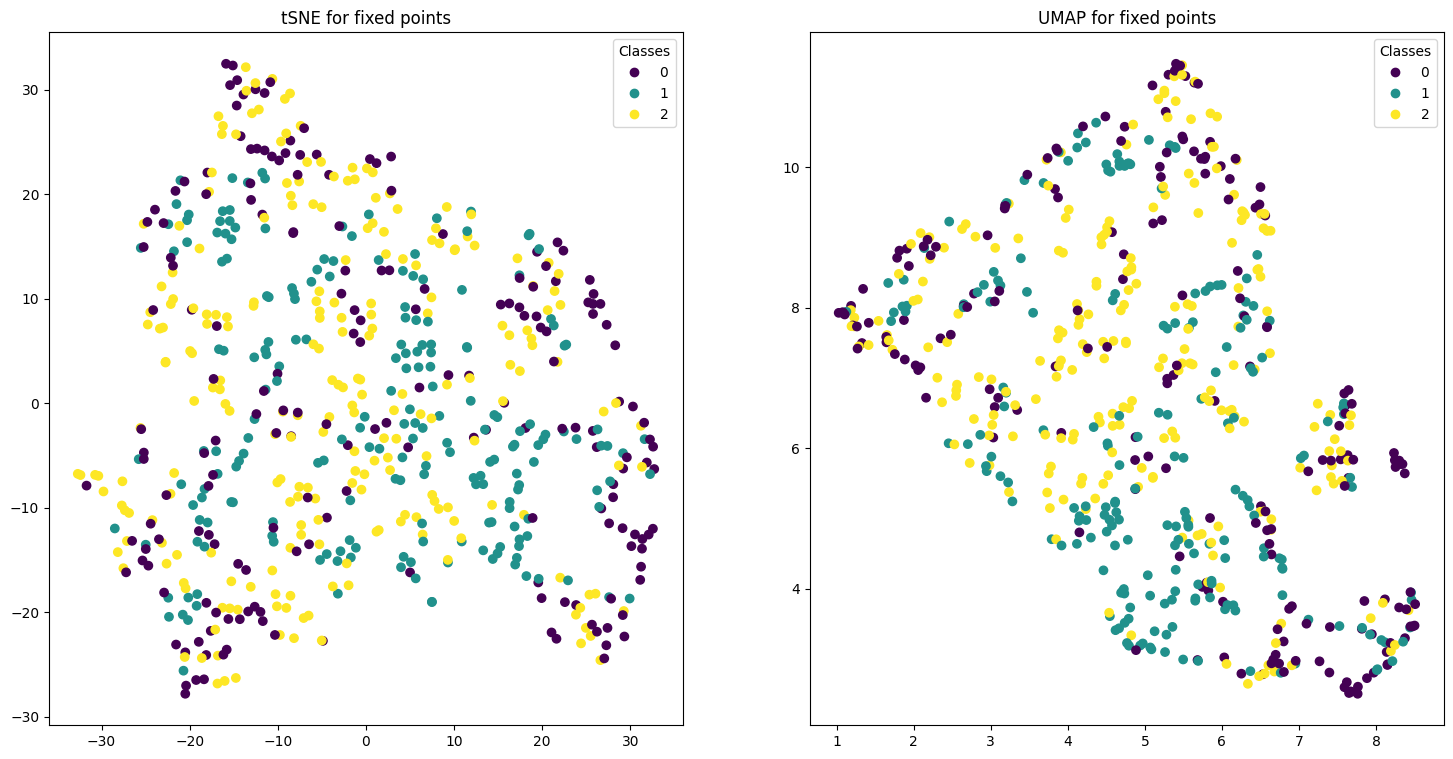

In [ ]:
tsne = TSNE()

tsne_embeds = tsne.fit_transform(X)
umap_embeds = umap.UMAP().fit_transform(X)
print(tsne_embeds.shape, umap_embeds.shape)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18,9))
scatter = ax1.scatter(tsne_embeds[:, 0], tsne_embeds[:, 1], c=Y, cmap='viridis')
legend = ax1.legend(*scatter.legend_elements(), title="Classes")
ax1.set_title(f'tSNE for fixed points')
scatter = ax2.scatter(umap_embeds[:, 0], umap_embeds[:, 1], c=Y, cmap='viridis')
legend = ax2.legend(*scatter.legend_elements(), title="Classes")
ax2.set_title(f'UMAP for fixed points')


In [60]:
tot = [0,0,0]
for key, value in sym_dataset.items():
    tot[value] += 1
tot

[190, 205, 232]

In [ ]:

with open('data/sym_dataset.json', 'w') as f:
    json.dump(sym_dataset, f)


TypeError: keys must be str, int, float, bool or None, not tuple

In [ ]:
# how many board only have one move?
full_tot = 0
for key, _ in all_states.items():
    tot = 0
    for char in key:
        if char == ' ':
            tot += 1
    if tot == 1:
        full_tot += 1
full_tot

222

In [ ]:
# how many boards is playing in the center (when it is available) the best move
tot_plays = 0
tot = 0
for key, value in all_states.items():
    if key[4] == ' ':
        tot += 1
        if 4 in value:
            tot_plays += 1

print(f'{tot_plays}/{tot} = {tot_plays/tot}')

1323/1883 = 0.7026022304832714


Another challenge of the tictactoe parameter golf challenge is that the dataset is not fixed. More than half of the datapoints in the dataset admit more than one optimal solution. Sometimes it is useful to focus on the points in which there is a single answer, which we refer to as the `fixed_states`.

There is a lot of symmetry in the tictactoe dataset. Most board positions are one of 8 symmetric boards, with only 627 unique boards to learn up to symmetry. This is almost (as expected) an 8-fold reduction.

An initial idea was to find a function that maps each board to a rotation and reflection invariant representation, then feeding the representation to a smaller network. This reduces the data required for the network to learn, allowing for smaller sizes. However, the problem is that although the boards are D8 symmetric, the outputs are not. This could, for example, be used to make a small network that outputs whether the optimal answer is a corner, edge, or center, but clearly this is not sufficient for the challenge. There needs to be some way that the symmetry can be exploited while still preserving the 


